In [1]:
import pandas as pd
import sklearn
import fastapi
print("All good")

All good


In [2]:
import sys, pandas as pd
print(sys.executable)
print(pd.__version__)

c:\Users\USER\Documents\GitHub\cesar-v1\.venv\Scripts\python.exe
2.3.3


In [3]:
mlopsdataOLD = pd.read_csv('C:/Users/USER/Documents/GitHub/cesar-v1/data/archive/dvf_75115_000CM.csv', sep=';')
mlopsdataNEW = pd.read_csv('C:/Users/USER/Documents/GitHub/cesar-v1/data/dvf_75015_all_years.csv', sep=';')
mlopsdataNEW.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_31672\4075309287.py:2: DtypeWarning: Columns (8,18,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  mlopsdataNEW = pd.read_csv('C:/Users/USER/Documents/GitHub/cesar-v1/data/dvf_75015_all_years.csv', sep=';')


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2020-823674,2020-07-02,1,Vente,45000.0,37.0,NaN,RUE LECOURBE,5456,75015,...,Appartement,6.0,1.0,NaN,NaN,NaN,NaN,NaN,2.307931,48.843853
1,2020-823675,2020-07-02,1,Vente,365000.0,6.0,NaN,RUE FIZEAU,3656,75015,...,Appartement,38.0,3.0,NaN,NaN,NaN,NaN,NaN,2.302692,48.830807
2,2020-823676,2020-07-02,1,Vente,438225.0,36.0,NaN,RUE JEAN MARIDOR,4915,75015,...,Appartement,36.0,2.0,NaN,NaN,NaN,NaN,NaN,2.287270,48.838182
3,2020-823677,2020-07-06,1,Vente,29000.0,9.0,B,RUE ANTOINE BOURDELLE,0372,75015,...,Local industriel. commercial ou assimilé,12.0,0.0,NaN,NaN,NaN,NaN,NaN,2.318343,48.842644
4,2020-823678,2020-07-03,1,Vente,20000.0,106.0,NaN,RUE DE SEVRES,8955,75015,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.312614,48.845951


## Comparison: original (dvf_75115_000CM) vs new all-years (dvf_75015_all_years)

In [4]:
# 1. Shape
print("=== Shape ===")
print(f"OLD: {mlopsdataOLD.shape[0]:,} rows, {mlopsdataOLD.shape[1]} columns")
print(f"NEW: {mlopsdataNEW.shape[0]:,} rows, {mlopsdataNEW.shape[1]} columns")

# 2. Column differences
old_cols = set(mlopsdataOLD.columns)
new_cols = set(mlopsdataNEW.columns)
print("\n=== Column differences ===")
print(f"Only in OLD: {old_cols - new_cols}")
print(f"Only in NEW: {new_cols - old_cols}")

=== Shape ===
OLD: 50 rows, 41 columns
NEW: 38,683 rows, 40 columns

=== Column differences ===
Only in OLD: {'section_prefixe'}
Only in NEW: set()


In [5]:
# 3. Date range
print("=== Date range ===")
for label, df in [("OLD", mlopsdataOLD), ("NEW", mlopsdataNEW)]:
    dates = pd.to_datetime(df["date_mutation"], errors="coerce")
    print(f"{label}: {dates.min().date()} → {dates.max().date()}")

=== Date range ===
OLD: 2020-10-15 → 2025-03-28
NEW: 2020-07-01 → 2024-12-31


In [6]:
# 4. Data types comparison for shared columns
shared_cols = sorted(old_cols & new_cols)
dtype_comparison = pd.DataFrame({
    "OLD dtype": mlopsdataOLD[shared_cols].dtypes,
    "NEW dtype": mlopsdataNEW[shared_cols].dtypes,
})
dtype_comparison["match"] = dtype_comparison["OLD dtype"] == dtype_comparison["NEW dtype"]
print("=== Dtype mismatches ===")
print(dtype_comparison[~dtype_comparison["match"]])

=== Dtype mismatches ===
                             OLD dtype NEW dtype  match
adresse_numero                   int64   float64  False
adresse_suffixe                float64    object  False
code_nature_culture            float64    object  False
code_nature_culture_speciale   float64    object  False
lot1_numero                    float64    object  False
nature_culture                 float64    object  False
nature_culture_speciale        float64    object  False


In [7]:
# 5. Null rates for key pipeline columns
key_cols = ["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales",
            "code_departement", "type_local"]
print("=== Null rate (%) for key pipeline columns ===")
null_rates = pd.DataFrame({
    "OLD": mlopsdataOLD[key_cols].isnull().mean() * 100,
    "NEW": mlopsdataNEW[key_cols].isnull().mean() * 100,
}).round(1)
print(null_rates)

=== Null rate (%) for key pipeline columns ===
                            OLD   NEW
valeur_fonciere             0.0   1.2
surface_reelle_bati        64.0  50.2
nombre_pieces_principales  12.0   1.0
code_departement            0.0   0.0
type_local                 12.0   1.0


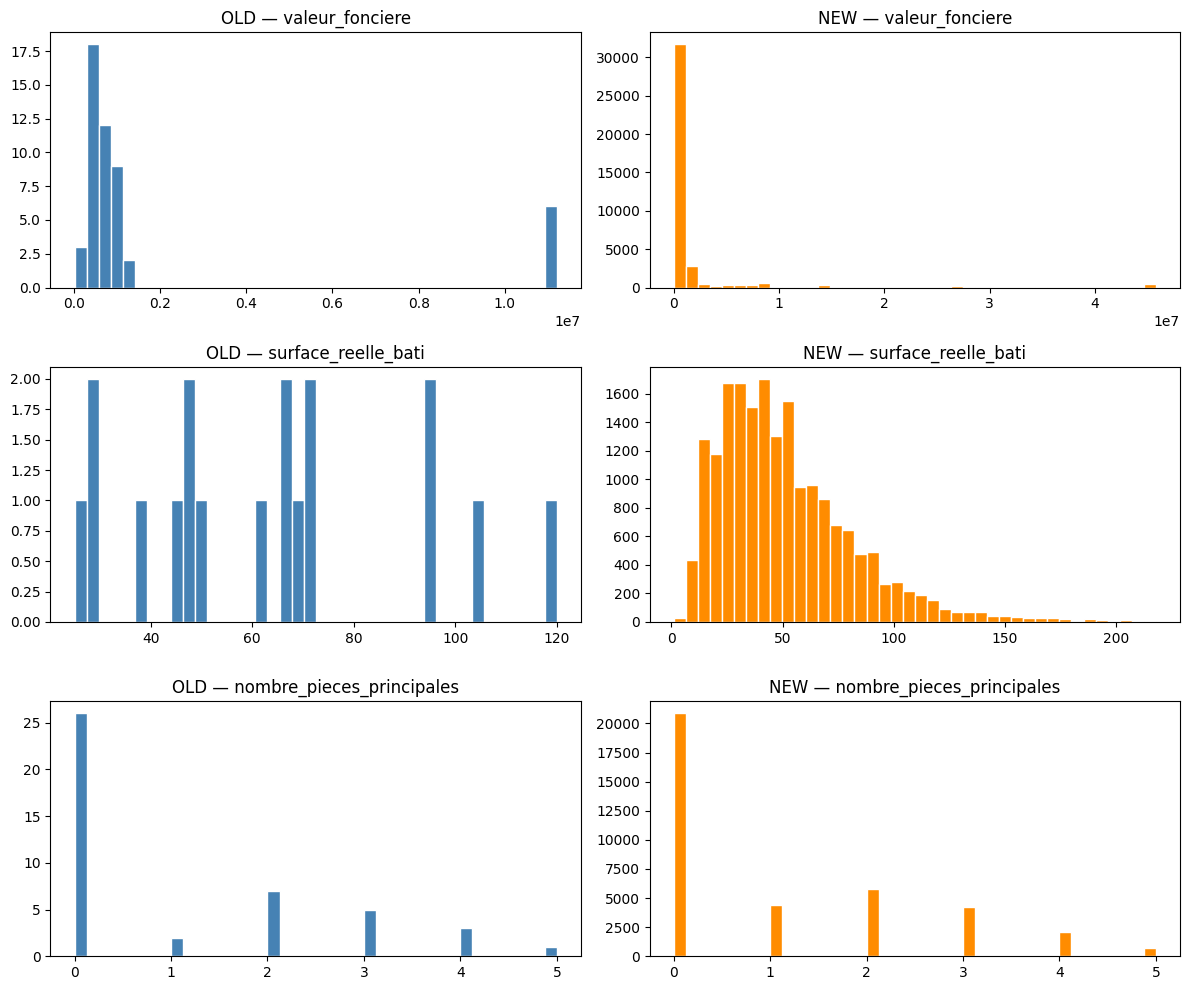

In [8]:
# 6. Distribution of key numeric columns
import matplotlib.pyplot as plt

numeric_cols = ["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales"]
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 10))

for i, col in enumerate(numeric_cols):
    old_vals = pd.to_numeric(mlopsdataOLD[col], errors="coerce").dropna()
    new_vals = pd.to_numeric(mlopsdataNEW[col], errors="coerce").dropna()

    # Cap outliers at 99th percentile for readability
    cap = max(old_vals.quantile(0.99), new_vals.quantile(0.99))
    old_vals = old_vals[old_vals <= cap]
    new_vals = new_vals[new_vals <= cap]

    axes[i, 0].hist(old_vals, bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"OLD — {col}")

    axes[i, 1].hist(new_vals, bins=40, color="darkorange", edgecolor="white")
    axes[i, 1].set_title(f"NEW — {col}")

plt.tight_layout()
plt.show()

In [9]:
# 7. type_local distribution
print("=== type_local distribution (%) ===")
for label, df in [("OLD", mlopsdataOLD), ("NEW", mlopsdataNEW)]:
    counts = df["type_local"].value_counts(normalize=True).mul(100).round(1)
    print(f"\n{label}:")
    print(counts.to_string())

=== type_local distribution (%) ===

OLD:
type_local
Dépendance     59.1
Appartement    40.9

NEW:
type_local
Dépendance                                  49.7
Appartement                                 45.4
Local industriel. commercial ou assimilé     4.7
Maison                                       0.2


## Apartments appearing in multiple years (repeated transactions)

In [14]:
# Load all arrondissement files and check for properties sold in multiple years
import glob

all_files = glob.glob('C:/Users/USER/Documents/GitHub/cesar-v1/data/dvf_*_all_years.csv')
frames = []
for f in sorted(all_files):
    df = pd.read_csv(f, sep=';', low_memory=False, usecols=[
        'id_parcelle', 'adresse_nom_voie', 'adresse_numero', 'code_postal',
        'type_local', 'surface_reelle_bati', 'valeur_fonciere', 'date_mutation'
    ])
    frames.append(df)

all_data = pd.concat(frames, ignore_index=True)

# Filter to Appartements only (matching pipeline)
apparts = all_data[all_data['type_local'] == 'Appartement'].copy()
apparts['year'] = pd.to_datetime(apparts['date_mutation'], errors='coerce').dt.year

# Identify properties sold in more than one year using parcel ID + address as key
identity_cols = ['id_parcelle', 'adresse_numero', 'adresse_nom_voie', 'code_postal', 'surface_reelle_bati']
apparts_clean = apparts.dropna(subset=['id_parcelle'])

years_per_property = apparts_clean.groupby(identity_cols)['year'].nunique()
repeated = years_per_property[years_per_property > 1]

print(f"Total Appartement rows: {len(apparts_clean):,}")
print(f"Unique properties: {len(years_per_property):,}")
print(f"Properties sold in multiple years: {len(repeated):,} ({len(repeated)/len(years_per_property)*100:.1f}%)")
print()

# Show a sample of repeat-sale properties with their transaction history
repeat_keys = repeated.index.to_frame(index=False).head(5)
print("=== Sample repeat-sale properties ===")
for _, row in repeat_keys.iterrows():
    mask = pd.Series(True, index=apparts_clean.index)
    for col in identity_cols:
        mask &= apparts_clean[col] == row[col]
    history = apparts_clean[mask][['date_mutation', 'valeur_fonciere', 'year']].sort_values('date_mutation')
    print(f"\n{row['adresse_numero']} {row['adresse_nom_voie']} ({row['code_postal']}) — {row['surface_reelle_bati']}m²")
    print(history.to_string(index=False))

Total Appartement rows: 171,078
Unique properties: 131,180
Properties sold in multiple years: 16,563 (12.6%)

=== Sample repeat-sale properties ===

58.0 QUAI DES ORFEVRES (75001) — 95.0m²
date_mutation  valeur_fonciere  year
   2022-07-18        2860000.0  2022
   2023-01-23          32000.0  2023
   2023-06-09          39000.0  2023
   2023-06-09          39000.0  2023

29.0 PL DAUPHINE (75001) — 50.0m²
date_mutation  valeur_fonciere  year
   2020-11-02        1035000.0  2020
   2021-02-03        1230000.0  2021
   2021-03-23         840000.0  2021
   2023-10-03        1250000.0  2023

43.0 RUE DE RIVOLI (75001) — 102.0m²
date_mutation  valeur_fonciere  year
   2022-04-12        1140000.0  2022
   2024-07-01        1953964.0  2024

9.0 RUE SAINT GERMAIN L AUXERROIS (75001) — 29.0m²
date_mutation  valeur_fonciere  year
   2021-12-16         385000.0  2021
   2023-08-29         450000.0  2023

10.0 QUAI DE LA MEGISSERIE (75001) — 66.0m²
date_mutation  valeur_fonciere  year
   2021-11-0

In [15]:
# Sanity check: count rows belonging to repeat-sale properties
repeat_mask = apparts_clean.set_index(identity_cols).index.isin(repeated.index)
print(f"Rows belonging to repeat-sale properties: {repeat_mask.sum():,}")
print(f"Expected minimum (2 sales × {len(repeated):,} properties): {len(repeated)*2:,}")

Rows belonging to repeat-sale properties: 43,953
Expected minimum (2 sales × 16,563 properties): 33,126
